# Financial Data Pipeline & Fundamental Analysis

## Objetivo
Construir un pipeline completo de datos financieros:

1. Extracción desde API (Financial Modeling Prep)
2. Transformación en Pandas
3. Carga en base de datos MySQL
4. Consulta estructurada
5. Cálculo de métricas financieras clave
6. Análisis fundamental del negocio

---

Este notebook representa la versión limpia y estructurada del pipeline.

In [13]:
#Imports y configuración

import os
import sys
import requests
import pandas as pd
from dotenv import load_dotenv

# Añadimos src al path
sys.path.append("../src")

from functions import create_connection, calculate_financial_metrics, calculate_cagr

In [14]:
#Variables de entorno

load_dotenv("../.env")

API_KEY = os.getenv("FMP_API_KEY")
DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

symbol = "AAPL"

## 1. Extracción de datos desde API
Obtenemos los estados financieros (Income Statement) desde Financial Modeling Prep.

In [15]:
url = f"https://financialmodelingprep.com/stable/income-statement?symbol={symbol}&limit=5&apikey={API_KEY}"

response = requests.get(url)

if response.status_code != 200:
    raise Exception(f"Error en la API: {response.status_code}")

data = response.json()

df_raw = pd.DataFrame(data)
df_raw.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,revenue,costOfRevenue,...,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,2025-09-27,AAPL,USD,0000320193,2025-10-31,2025-10-31 06:01:26,2025,FY,416161000000,220960000000,...,112010000000,0,0,112010000000,0,112010000000,7.49,7.46,14948500000,15004697000
1,2024-09-28,AAPL,USD,0000320193,2024-11-01,2024-11-01 06:01:36,2024,FY,391035000000,210352000000,...,93736000000,0,0,93736000000,0,93736000000,6.11,6.08,15343783000,15408095000
2,2023-09-30,AAPL,USD,0000320193,2023-11-03,2023-11-02 18:08:27,2023,FY,383285000000,214137000000,...,96995000000,0,0,96995000000,0,96995000000,6.16,6.13,15744231000,15812547000
3,2022-09-24,AAPL,USD,0000320193,2022-10-28,2022-10-27 18:01:14,2022,FY,394328000000,223546000000,...,99803000000,0,0,99803000000,0,99803000000,6.15,6.11,16215963000,16325819000
4,2021-09-25,AAPL,USD,0000320193,2021-10-29,2021-10-28 18:04:28,2021,FY,365817000000,212981000000,...,94680000000,0,0,94680000000,0,94680000000,5.67,5.61,16701272000,16864919000


## 2. Transformación y selección de variables relevantes

Seleccionamos únicamente las variables necesarias para el análisis financiero.

In [16]:
columns_selected = [
    "fiscalYear",
    "period",
    "date",
    "revenue",
    "costOfRevenue",
    "grossProfit",
    "operatingIncome",
    "netIncome",
    "eps"
]

df = df_raw[columns_selected].copy()

# Ordenamos cronológicamente
df = df.sort_values("fiscalYear")

df.reset_index(drop=True, inplace=True)

df

,fiscalYear,period,date,revenue,costOfRevenue,grossProfit,operatingIncome,netIncome,eps
0,2021,FY,2021-09-25,365817000000,212981000000,152836000000,108949000000,94680000000,5.67
1,2022,FY,2022-09-24,394328000000,223546000000,170782000000,119437000000,99803000000,6.15
2,2023,FY,2023-09-30,383285000000,214137000000,169148000000,114301000000,96995000000,6.16
3,2024,FY,2024-09-28,391035000000,210352000000,180683000000,123216000000,93736000000,6.11
4,2025,FY,2025-09-27,416161000000,220960000000,195201000000,133050000000,112010000000,7.49


## 3. Conexión a base de datos MySQL
Establecemos conexión utilizando variables de entorno.

In [17]:
connection = create_connection(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME
)

if connection is None:
    raise Exception("No se pudo establecer conexión con la base de datos")

cursor = connection.cursor()

In [18]:
#Creamos tabla, si no existese
create_table_query = """
CREATE TABLE IF NOT EXISTS income_statements (
    id INT AUTO_INCREMENT PRIMARY KEY,
    fiscal_year INT,
    period VARCHAR(10),
    report_date DATE,
    revenue BIGINT,
    cost_of_revenue BIGINT,
    gross_profit BIGINT,
    operating_income BIGINT,
    net_income BIGINT,
    eps FLOAT
);
"""

cursor.execute(create_table_query)
connection.commit()

In [19]:
#Inserción de data desde el DF

insert_query = """
INSERT INTO income_statements (
    fiscal_year, period, report_date,
    revenue, cost_of_revenue, gross_profit,
    operating_income, net_income, eps
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

for _, row in df.iterrows():
    cursor.execute(insert_query, (
        row["fiscalYear"],
        row["period"],
        row["date"],
        row["revenue"],
        row["costOfRevenue"],
        row["grossProfit"],
        row["operatingIncome"],
        row["netIncome"],
        row["eps"]
    ))

connection.commit()

In [20]:
cursor.execute("SELECT COUNT(*) FROM income_statements")
print("Filas insertadas:", cursor.fetchone()[0])

Filas insertadas: 10


In [21]:
#Lectura desde database
query = """
SELECT fiscal_year, revenue, net_income
FROM income_statements
ORDER BY fiscal_year;
"""

df_sql = pd.read_sql(query, connection)
df_sql

/var/folders/qz/lqkm42d57sxb3jcp56ssgksm0000gn/T/ipykernel_7214/2291220642.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query, connection)


,fiscal_year,revenue,net_income
0,2021,365817000000,94680000000
1,2021,365817000000,94680000000
2,2022,394328000000,99803000000
3,2022,394328000000,99803000000
4,2023,383285000000,96995000000
5,2023,383285000000,96995000000
6,2024,391035000000,93736000000
7,2024,391035000000,93736000000
8,2025,416161000000,112010000000
9,2025,416161000000,112010000000


In [22]:
#Recalculamos métricas

df_sql["revenue_yoy_%"] = df_sql["revenue"].pct_change() * 100
df_sql["net_income_yoy_%"] = df_sql["net_income"].pct_change() * 100
df_sql["net_margin_%"] = (df_sql["net_income"] / df_sql["revenue"]) * 100

df_sql

,fiscal_year,revenue,net_income,revenue_yoy_%,net_income_yoy_%,net_margin_%
0,2021,365817000000,94680000000,NaN,NaN,25.881793
1,2021,365817000000,94680000000,0.000000,0.000000,25.881793
2,2022,394328000000,99803000000,7.793788,5.410858,25.309641
3,2022,394328000000,99803000000,0.000000,0.000000,25.309641
4,2023,383285000000,96995000000,-2.800461,-2.813543,25.306234
5,2023,383285000000,96995000000,0.000000,0.000000,25.306234
6,2024,391035000000,93736000000,2.021994,-3.359967,23.971256
7,2024,391035000000,93736000000,0.000000,0.000000,23.971256
8,2025,416161000000,112010000000,6.425512,19.495178,26.915064
9,2025,416161000000,112010000000,0.000000,0.000000,26.915064


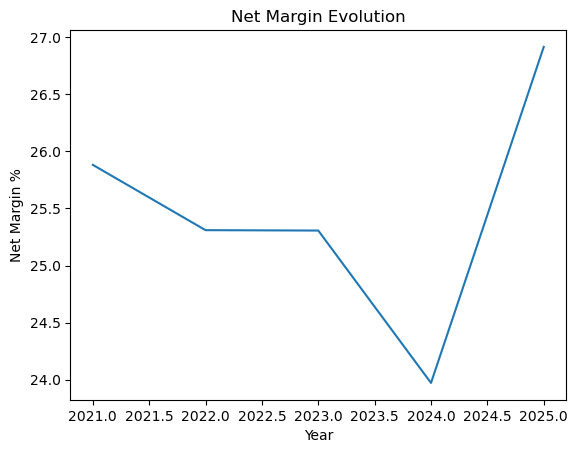

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_sql["fiscal_year"], df_sql["net_margin_%"])
plt.title("Net Margin Evolution")
plt.xlabel("Year")
plt.ylabel("Net Margin %")
plt.show()

📊 Análisis de evolución financiera (2021–2025)
1️⃣ Fase de normalización (2021–2022)

Crecimiento sólido en ingresos (+7.8%)

Beneficio creciendo en línea (+5.4%)

Ligera compresión de márgenes
Lectura: expansión madura y controlada.

2️⃣ Fase de desaceleración (2022–2023)

Caída de ingresos (-2.8%)

Beneficio cae en proporción similar

Margen estable (~25%)

Lectura: desaceleración cíclica sin deterioro estructural.
La estabilidad del margen indica control de costes.

3️⃣ Fase de presión operativa (2023–2024)

Ingresos ligeramente al alza (+2%)

Beneficio a la baja (-3.3%)

Margen cae a ~24%

Lectura: presión en costes o menor eficiencia operativa.
Posible inversión estratégica o compresión temporal del mix.

4️⃣ Fase de expansión operativa (2024–2025)

Ingresos +6.4%

Beneficio +19.5%

Margen en máximos (~26.9%)

Lectura: fuerte leverage operativo y recuperación del pricing power.
El crecimiento del beneficio supera ampliamente al crecimiento del revenue.

🧠 Conclusión estratégica

El comportamiento no sugiere deterioro estructural.
Se observa:

Resiliencia en márgenes durante la desaceleración

Capacidad de recuperación eficiente

Evidencia de ventaja competitiva sostenible

La empresa muestra características de compounder defensivo con capacidad de expansión de márgenes en fase favorable del ciclo.